### Inference-Time Scaling via self-refinement 
--- i am following sebastian_rashcka's notebooks to build strong foundation..

#### Scoring and iteratively improving model responses

* Loading a pre-trained model

In [1]:
from pathlib import Path
import sys
import torch

ROOT_DIR = Path.cwd().parent  # Get parent of current directory
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))


from evaluating_reasoning_models.model_and_tokenizer import load_model_and_tokenizer

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    use_compile=False
)


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [2]:
from improving_reasoning_with_inference_time_scaling.improving_reasoning_with_inference_time_scaling import (
    generate_text_stream_concat_flex,
    generate_text_top_p_stream_cache,
)
from evaluating_reasoning_models.evaluating_reasoning_models import render_prompt

device = "cuda" if torch.cuda.is_available() else "cpu"
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)




prompt_cot = render_prompt(raw_prompt + "\n\nExplain the problem step by step")
print(prompt_cot)

torch.manual_seed(0)
response_1 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=1048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.2,
    top_p=0.9,
)


You are a helpful math assistant.

Solve the problem step by step.
The last line of your response should contain only the final answer inside \boxed{}.

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Explain the problem step by step

Answer:

\boxed{10}



In [ ]:
torch.manual_seed(1)
response_2 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=1048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.2,
    top_p=0.9,
)


\boxed{15}



In [4]:
print("Response 1 characters:", len(response_1))
print("Response 1 tokens:", len(tokenizer.encode(response_1)))
print("Response 2 characters:", len(response_2))
print("Response 2 tokens:", len(tokenizer.encode(response_2)))


Response 1 characters: 12
Response 1 tokens: 6
Response 2 characters: 12
Response 2 tokens: 6


#### Scoring llm responses with a role-based score

In [5]:
from evaluating_reasoning_models.evaluating_reasoning_models import extract_final_candidate
import math

def heuristic_score(
    answer,
    prompt=None,  
    brevity_bonus=500.0,
    boxed_bonus=2.0,
    extract_bonus=1.0,
    fulltext_bonus=0.0,
):
    score = 0.0

    # Reward answers that have a final boxed value
    cand = extract_final_candidate(answer, fallback="none")
    if cand:
        score += boxed_bonus

    # Give weaker rewards if answer doesn't have a boxed value
    else:
        cand = extract_final_candidate(answer, fallback="number_only")
        if cand:
            score += extract_bonus
        else:
            cand = extract_final_candidate(
                answer, fallback="number_then_full"
            )
            if cand:
                score += fulltext_bonus

    # Add a brevity reward that decays with text length
    score += 1.5 * math.exp(-len(answer) / brevity_bonus)
    return score

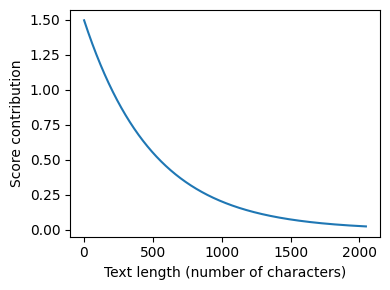

In [ ]:
import matplotlib.pyplot as plt

def plot_brevity_curve(brevity_bonus, max_len=2048):
    lengths = torch.arange(1, max_len) ## from 1, 2048
    scores = 1.5 * torch.exp(-lengths / brevity_bonus) ## -lengths/brevity_bonus

    plt.figure(figsize=(4,3))
    plt.plot(lengths, scores)
    plt.xlabel("Text length (number of characters)")
    plt.ylabel("Score contribution")
    plt.tight_layout()
    plt.show()

plot_brevity_curve(500)


In [7]:
print(heuristic_score(response_1))

3.464428564636864


In [8]:
print(round(heuristic_score(response_1), 3))

3.464


In [9]:
print(round(heuristic_score(response_2), 3))

3.464


#### Understanding token probability scores

In [10]:
import torch

@torch.inference_mode()
def calc_next_token_probas(model, tokenizer, prompt, device, show=True):

    # Convert text into token IDs
    token_ids = torch.tensor(tokenizer.encode(prompt), device=device)

    # Get next-token logits for every position
    logits = model(token_ids.unsqueeze(0)).squeeze(0)

    # Convert logits -> probabilities
    all_probas = torch.softmax(logits, dim=-1)

    # Positions whose predictions we want to score
    t_idx = torch.arange(0, token_ids.shape[0] - 1, device=device)

    # Ground-truth next tokens in the sequence (cause we already have the generated text)
    next_ids = token_ids[1:]

    # Probability assigned to each correct next token
    next_token_probas = all_probas[t_idx, next_ids]

    # Joint likelihood of the sequence
    prod_next_token_probas = torch.prod(next_token_probas)

    if show:
        print("Next-token probabilities:", next_token_probas)
        print("Joint probability:", prod_next_token_probas)
    else:
        return next_token_probas, prod_next_token_probas

In [11]:
torch.set_printoptions(precision=4, sci_mode=True)

In [12]:
calc_next_token_probas(model, tokenizer, device=device, prompt="Large langauge models are trained")

Next-token probabilities: tensor([2.9922e-05, 2.2705e-02, 1.3367e-02, 1.1182e-01, 7.0312e-02],
       device='cuda:0', dtype=torch.bfloat16)
Joint probability: tensor(7.1395e-11, device='cuda:0', dtype=torch.bfloat16)


In [13]:
calc_next_token_probas(model, tokenizer, device=device, prompt="Large langauge models are typically")

Next-token probabilities: tensor([2.9922e-05, 2.2705e-02, 1.3367e-02, 1.1182e-01, 5.1270e-02],
       device='cuda:0', dtype=torch.bfloat16)
Joint probability: tensor(5.2069e-11, device='cuda:0', dtype=torch.bfloat16)


In [14]:
calc_next_token_probas(model, tokenizer, device=device, prompt="Large langauge models are used")


Next-token probabilities: tensor([2.9922e-05, 2.2705e-02, 1.3367e-02, 1.1182e-01, 2.1362e-02],
       device='cuda:0', dtype=torch.bfloat16)
Joint probability: tensor(2.1714e-11, device='cuda:0', dtype=torch.bfloat16)


### from token probability scores to log-probabilities

In [15]:
torch.set_printoptions(precision=4, sci_mode=False)

In [16]:
logits = torch.linspace(-2,2, steps=7)
probas = torch.softmax(logits, dim=-1)
print(probas)

tensor([0.0090, 0.0175, 0.0341, 0.0665, 0.1295, 0.2522, 0.4912])


In [17]:
print(torch.log(probas))

tensor([-4.7109, -4.0442, -3.3776, -2.7109, -2.0442, -1.3776, -0.7109])


In [18]:
log_probas =  torch.log_softmax(logits, dim=-1)
print(log_probas)

tensor([-4.7109, -4.0442, -3.3776, -2.7109, -2.0442, -1.3776, -0.7109])


** now using log probability

In [19]:
@torch.inference_mode()
def calc_next_token_logprobas(model, tokenizer, prompt, device, show=True):

    # Convert text into token IDs
    token_ids = torch.tensor(tokenizer.encode(prompt), device=device)

    # Get next-token logits for every position
    logits = model(token_ids.unsqueeze(0)).squeeze(0)

    # Convert logits -> log-probabilities
    all_logprobas = torch.log_softmax(logits, dim=-1)

    # Positions whose predictions we want to score
    t_idx = torch.arange(0, token_ids.shape[0] - 1, device=device)

    # Ground-truth next tokens in the sequence
    next_ids = token_ids[1:]

    # Log-probability assigned to each correct next token
    next_token_logprobas = all_logprobas[t_idx, next_ids]

    # Joint log-likelihood of the sequence
    sum_next_token_logprobas = torch.sum(next_token_logprobas)

    if show:
        print("Next-token log-probabilities:", next_token_logprobas)
        print("Joint log-probability:", sum_next_token_logprobas)

    else:
        return next_token_logprobas, sum_next_token_logprobas

In [20]:
calc_next_token_logprobas(model, tokenizer, device=device, prompt="Large language models are trained")

Next-token log-probabilities: tensor([-11.1875,  -0.2930,  -2.8906,  -2.6250], device='cuda:0',
       dtype=torch.bfloat16)
Joint log-probability: tensor(-17., device='cuda:0', dtype=torch.bfloat16)


In [ ]:
calc_next_token_logprobas(model, tokenizer, device=device, prompt="Large langauge models are used")


Next-token log-probabilities: tensor([-10.4375,  -3.7812,  -4.3125,  -2.1875,  -3.8438], device='cuda:0',
       dtype=torch.bfloat16)
Joint log-probability: tensor(-24.5000, device='cuda:0', dtype=torch.bfloat16)


In [ ]:
calc_next_token_logprobas(model, tokenizer, device=device, prompt="Large langauge models are typically")


Next-token log-probabilities: tensor([-10.4375,  -3.7812,  -4.3125,  -2.1875,  -2.9688], device='cuda:0',
       dtype=torch.bfloat16)
Joint log-probability: tensor(-23.7500, device='cuda:0', dtype=torch.bfloat16)


### Scoring model confidence with log-probabilities

In [ ]:
example_prompt = "What is the capital of France?"
example_answer = "The capital of france is Paris"

next_token_logprobas, sum_next_token_logprobas = calc_next_token_logprobas(
    model,
    tokenizer,
    prompt=example_prompt + example_answer,
    device=device,
    show=False
)

print("Next-token logprobas:", next_token_logprobas)
print("Joint log-probability:", sum_next_token_logprobas)

Next-token logprobas: tensor([-10.0000,  -0.1133,  -8.5625,  -0.3320,  -4.9062,  -1.4688,  -7.8750,
         -1.7031,  -0.0791,  -8.5625,  -0.2051,  -1.3125], device='cuda:0',
       dtype=torch.bfloat16)
Joint log-probability: tensor(-45., device='cuda:0', dtype=torch.bfloat16)


In [24]:
print(len(tokenizer.encode(example_answer)))

6


In [25]:
last6 = next_token_logprobas[-6:] ## getting the answer tokens
print(last6)

tensor([-7.8750, -1.7031, -0.0791, -8.5625, -0.2051, -1.3125], device='cuda:0',
       dtype=torch.bfloat16)


In [26]:
print(torch.mean(last6))

tensor(-3.2969, device='cuda:0', dtype=torch.bfloat16)


In [54]:
@torch.inference_mode()
def avg_logprob_answer(model, tokenizer, prompt, answer, device="cpu"):

    # Encode prompt and answer tokens separately to get the prompt length later
    prompt_ids = tokenizer.encode(prompt)
    answer_ids = tokenizer.encode(answer)
    full_ids = torch.tensor(prompt_ids + answer_ids, device=device)

    # Same as in calc_next_token_logprobas before
    logits = model(full_ids.unsqueeze(0)).squeeze(0)
    logprobs = torch.log_softmax(logits, dim=-1)

    # Index range for positions corresponding to answer tokens
    start = len(prompt_ids) - 1
    end = full_ids.shape[0] - 1

    # Same as before, except for using start and end
    t_idx = torch.arange(start, end, device=device)
    next_tokens = full_ids[start + 1 : end + 1]
    next_token_logps = logprobs[t_idx, next_tokens]

    # Average over the answer token scores
    return torch.mean(next_token_logps)

In [ ]:
sc_1 = avg_logprob_answer(
    model, tokenizer, 
    prompt="What is the capital of France?", 
    answer="The capital of france is Paris",
    device=device)

print(sc_1)

tensor(-3.2969, device='cuda:0', dtype=torch.bfloat16)


In [ ]:
sc_2 = avg_logprob_answer(
    model, tokenizer, 
    prompt="What is the capital of France?", 
    answer="The capital of france is Belgium",
    device=device)

print(sc_2)

tensor(-4.6562, device='cuda:0', dtype=torch.bfloat16)


In [ ]:
avg_logprob_answer(
    model, tokenizer,
    prompt=prompt_cot,
    answer=response_1,
    device=device
)

tensor(-0.6367, device='cuda:0', dtype=torch.bfloat16)

In [ ]:
avg_logprob_answer(
    model, tokenizer,
    prompt=prompt_cot,
    answer=response_2,
    device=device
)

tensor(-0.6797, device='cuda:0', dtype=torch.bfloat16)

#### Self-refinement through iterative feedback

In [32]:
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)

initial_response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9, 
)

\boxed{x=10

}



In [55]:
def make_critique_prompt(raw_prompt, draft):
    return (
        "You are an expert verifier.\n\n"

        "First solve the problem independently in your head. "
        "Then compare your solution to the draft answer.\n\n"

        f"Question:\n{raw_prompt}\n\n"
        f"Draft answer:\n{draft}\n\n"

        "Output:\n"
        "Verdict: Correct or Incorrect\n"
        "Critique: Explain any mistakes.\n"
        "Fix Plan: List the necessary corrections.\n\n"

        "Do not assume the draft is correct."
    )
critique_prompt = make_critique_prompt(raw_prompt, initial_response)
torch.manual_seed(123)
critique = generate_text_stream_concat_flex(
    model, tokenizer, critique_prompt, device,
    max_new_tokens=1000, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9, 
)



 Just solve the problem in your own way.
Answer:


\boxed{x=10}



In [56]:
def make_refine_prompt(raw_prompt, draft, critique):
    return (
        "You are revising an answer based on reviewer feedback.\n\n"

        "Carefully address all valid issues identified in the critique. "
        "Preserve any reasoning that is already correct. "
        "Do not mention the critique or explain your revision process. "
        "Produce only the improved answer.\n\n"

        f"Question:\n{raw_prompt}\n\n"
        f"Previous Answer:\n{draft}\n\n"
        f"Critique:\n{critique}\n\n"

        "Requirements:\n"
        "- Correct any mistakes.\n"
        "- Add missing reasoning if needed.\n"
        "- Remove unsupported claims.\n"
        "- Be concise and accurate.\n"
        "- End with a final answer in the format: \\boxed{ANSWER}\n\n"

        "Revised Answer:"
    )

refine_prompt = make_refine_prompt(raw_prompt, initial_response, critique)
torch.manual_seed(123)
revised_answer = generate_text_stream_concat_flex(
    model, tokenizer, refine_prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9, 
)

 \boxed{x=10}


#### Self-refinement loop

In [61]:
def self_refinement_loop(
    model,
    tokenizer,
    raw_prompt,
    device,
    iterations=2,
    max_response_tokens=2048,
    max_critique_tokens=256,
    score_fn=None,
    prompt_renderer=render_prompt,
    prompt_suffix="",
    verbose=False,
    temperature=0.2,
    top_p=0.9,
):
    steps = []

    # --------------------------------------------------
    # Initial draft
    # --------------------------------------------------
    prompt = prompt_renderer(raw_prompt) + prompt_suffix

    current_full = generate_text_stream_concat_flex(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        device=device,
        max_new_tokens=max_response_tokens,
        verbose=False,
        generate_func=generate_text_top_p_stream_cache,
        temperature=temperature,
        top_p=top_p,
    )

    current_extracted = extract_final_candidate(
        current_full,
        fallback="number_then_full",
    )

    if score_fn:
        current_score = score_fn(
            answer=current_full,
            prompt=prompt,
        )
    else:
        current_score = 0.0

    # --------------------------------------------------
    # Refinement iterations
    # --------------------------------------------------
    for it in range(iterations):

        draft_before_full = current_full
        draft_before_extracted = current_extracted
        score_before = current_score

        # ----------------------------------------------
        # Critique current answer
        # ----------------------------------------------
        critique_prompt = make_critique_prompt(
            raw_prompt,
            draft_before_full,
        )

        critique_full = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=critique_prompt,
            device=device,
            max_new_tokens=max_critique_tokens,
            verbose=False,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature,
            top_p=top_p,
        )

        # ----------------------------------------------
        # Generate revised answer
        # ----------------------------------------------
        refine_prompt = make_refine_prompt(
            raw_prompt,
            draft_before_full,
            critique_full,
        )

        revised_full = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=refine_prompt,
            device=device,
            max_new_tokens=max_response_tokens,
            verbose=False,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature,
            top_p=top_p,
        )

        revised_extracted = extract_final_candidate(
            revised_full,
            fallback="number_then_full",
        )

        # ----------------------------------------------
        # Score revised answer
        # ----------------------------------------------
        if score_fn:
            revised_score = score_fn(
                answer=revised_full,
                prompt=prompt,  # original question prompt
            )
        else:
            revised_score = 0.0

        # ----------------------------------------------
        # Log step
        # ----------------------------------------------
        step = {
            "iteration": it + 1,
            "draft_full": draft_before_full,
            "draft_extracted": draft_before_extracted,
            "critique": critique_full,
            "revised_full": revised_full,
            "revised_extracted": revised_extracted,
            "score_before": score_before,
            "score_after": revised_score,
        }

        steps.append(step)

        if verbose:
            print(
                f"[Refinement {it+1}/{iterations}]"
                f"\nCurrent Extracted: {draft_before_extracted}"
                f"\nRevised Extracted: {revised_extracted}"
                f"\nScore before: {score_before:.3f}"
                f"\nScore after: {revised_score:.3f}"
                f"\n{'=' * 25}"
            )

        # ----------------------------------------------
        # Accept if not worse
        # ----------------------------------------------
        if revised_score >= current_score:
            current_full = revised_full
            current_extracted = revised_extracted
            current_score = revised_score

    # --------------------------------------------------
    # Final result
    # --------------------------------------------------
    return {
        "final_full": current_full,
        "final_extracted": current_extracted,
        "steps": steps,
    }


In [62]:
from functools import partial

avg_logprob_score = partial(
    avg_logprob_answer,
    model=model,
    tokenizer=tokenizer,
    device=device
)


In [63]:
torch.manual_seed(1)

results_logprob = self_refinement_loop(
    model=model,
    tokenizer=tokenizer,
    raw_prompt=raw_prompt,
    device=device,
    iterations=2,
    max_response_tokens=2048,
    max_critique_tokens=256,
    score_fn=avg_logprob_score,
    verbose=True,
    temperature=0.7,
    top_p=0.9,
)



[Refinement 1/2]
Current Extracted: x = 14
Revised Extracted: 83
Score before: -0.746
Score after: -2.844
[Refinement 2/2]
Current Extracted: x = 14
Revised Extracted: 83
Score before: -0.746
Score after: -2.844


In [51]:
print(results_logprob["final_extracted"])

x = 14


In [52]:
print(answer)
print(next_token_logps)
print(torch.mean(next_token_logps))

tensor(-6., device='cuda:0', dtype=torch.bfloat16)
tensor(-8.1250, device='cuda:0', dtype=torch.bfloat16)


In [53]:
print(tokenizer.encode("14"))
print(tokenizer.encode("83"))
print(len(tokenizer.encode("14")))
print(len(tokenizer.encode("83")))


[16, 19]
[23, 18]
2
2
